In [1]:
!pip install hmmlearn --quiet
!pip install yfinance --quiet
!pip install xgboost --quiet
!pip install pandas_datareader --quiet
!pip install imblearn --quiet
!pip install kagglehub --quiet
!pip install kaggle --quiet


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Importing Required LIbraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from hmmlearn import hmm
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
import pandas_datareader.data as web
from datetime import datetime

**Importing and Preparing Macro-Economic Data from FRED**

In [3]:
# Define date range
start_date = "2000-01-01"
end_date = "2018-12-31"#datetime.today().strftime('%Y-%m-%d')

# Pull Macro Data from FRED (Long history available)
fred_series = {
    "UNRATE": "unemployment",
    "FEDFUNDS": "fed_funds",
    'CPIAUCSL': 'cpi',
    'INDPRO': 'industrial_production',
    'GS10': 'gs10',
    'GS2': 'gs2',
    "BAA10Y": "credit_spread"
}
macro_data = web.DataReader(list(fred_series.keys()), 'fred', start_date, end_date)
macro_data.rename(columns=fred_series, inplace=True)
# Normalize macro_data index to month-end to align with resampled S&P 500
macro_data = macro_data.resample("ME").last()

# Use bfill then ffill to ensure all NaN values from original macro_data are filled before merging
#macro_data.bfill(inplace=True)
#macro_data.ffill(inplace=True)

# 3. Pull S&P 500 from yfinance (Bypasses FRED 10-year limit)
sp500_series = yf.download("^GSPC", start=start_date, end=end_date)['Close'] # Use a temporary name for the series
sp500_series.name = 'sp500' # Name the Series 'sp500'

# 4. Merge and Align
# Create df as a copy of macro_data and then assign the sp500_series directly to a column
df = macro_data.copy()

# Resample S&P 500 to month-end before assigning to align with macro_data's monthly index
sp500_monthly = sp500_series.resample("ME").last()
df['sp500'] = sp500_monthly

# Remove any columns that are entirely NaN (e.g., if a FRED series had no data for the period)
df = df.dropna(axis=1, how='all')

# 5. Frequency Alignment and Feature Engineering
# df is already monthly due to macro_data and sp500_monthly, so no need for df.resample("ME").last()

df['cpi_inflation'] = df['cpi'].pct_change()
df['ip_growth'] = df['industrial_production'].pct_change()
df['sp500_returns'] = df['sp500'].pct_change() # This should now work correctly
df['yield_curve'] = df['gs10'] - df['gs2']

# 6. Lag to avoid Look-Ahead Bias and Drop initial NaNs from pct_change

macro_econ_data = df.shift(1).dropna()

macro_econ_data.columns = [col + "_lag1" for col in macro_econ_data.columns]

print("Shape of macro_data_final after shift(1) and dropna():", macro_econ_data.shape)
display(macro_econ_data.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Shape of macro_data_final after shift(1) and dropna(): (226, 12)


,unemployment_lag1,fed_funds_lag1,cpi_lag1,industrial_production_lag1,gs10_lag1,gs2_lag1,credit_spread_lag1,sp500_lag1,cpi_inflation_lag1,ip_growth_lag1,sp500_returns_lag1,yield_curve_lag1
DATE,,,,,,,,,,,,
2000-03-31,4.1,5.73,170.0,91.8239,6.52,6.61,1.91,1366.420044,0.004135,0.003123,-0.020108,-0.09
2000-04-30,4.0,5.85,171.0,92.1504,6.26,6.53,2.30,1498.579956,0.005882,0.003556,0.096720,-0.27
2000-05-31,3.8,6.02,170.9,92.6989,5.99,6.40,2.34,1452.430054,-0.000585,0.005952,-0.030796,-0.41
2000-06-30,4.0,6.27,171.2,92.9499,6.44,6.81,2.52,1420.599976,0.001755,0.002708,-0.021915,-0.37
2000-07-31,4.0,6.53,172.2,92.9862,6.10,6.48,2.40,1454.599976,0.005841,0.000391,0.023934,-0.38


**2.0 Loading and Preparing Lending Club Data**

In [4]:
# Set up Kaggle API credentials from Colab secrets
import os
#from google.colab import userdata

os.environ['KAGGLE_USERNAME'] ='Wickliff Ogari' #userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = 'e47c0af8c846401cc875596217851d79' #userdata.get('KAGGLE_KEY')

# Import the Kaggle API client
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

# Define the dataset and file to download
dataset_name = 'wordsforthewise/lending-club'
file_name = 'accepted_2007_to_2018Q4.csv.gz'

# Create a directory to store the downloaded files
output_dir = './kaggle_data'
os.makedirs(output_dir, exist_ok=True)

# Download the specific file
print(f"Downloading {file_name} from {dataset_name}...")
api.dataset_download_file(
    dataset_name,
    file_name,
    path=output_dir
)
print("Download complete.")

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
Download complete.


In [5]:
# Unzip the downloaded file
import gzip
import shutil

zipped_file_path = os.path.join(output_dir, file_name)
unzipped_file_path = os.path.join(output_dir, file_name.replace('.gz', ''))

print(f"Unzipping {zipped_file_path} to {unzipped_file_path}...")
with gzip.open(zipped_file_path, 'rb') as f_in:
    with open(unzipped_file_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
print("Unzipping complete.")

Unzipping ./kaggle_data\accepted_2007_to_2018Q4.csv.gz to ./kaggle_data\accepted_2007_to_2018Q4.csv...
Unzipping complete.


Now, we can load the unzipped CSV file into a pandas DataFrame.

In [6]:
loans = pd.read_csv(unzipped_file_path, engine='pyarrow')

# Convert to datetime while forcing errors to 'NaT' (Not a Time)
# This prevents the "Unknown datetime string format" crash
loans['issue_d'] = pd.to_datetime(loans['issue_d'], errors='coerce')

# Clean up: Drop rows where the date is missing (the summary rows at the end)
loans = loans.dropna(subset=['issue_d'])

# Create issue_month and sort
loans['issue_month'] = loans['issue_d']
loans = loans.sort_values('issue_month')

print("Loans data loaded and cleaned successfully!")
print(loans[['issue_month']].head())


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6868\933559107.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  loans['issue_d'] = pd.to_datetime(loans['issue_d'], errors='coerce')


Loans data loaded and cleaned successfully!
        issue_month
1654413  2007-06-01
1654392  2007-06-01
1654393  2007-06-01
1654394  2007-06-01
1654395  2007-06-01


In [7]:
print("Start date:", loans['issue_month'].min())
print("End date:", loans['issue_month'].max())

Start date: 2007-06-01 00:00:00
End date: 2018-12-01 00:00:00


In [9]:
# Binary target: 1 = default, 0 = non-default
loans['default'] = loans['loan_status'].isin([
    'Charged Off', 'Default'
]).astype(int)

In [ ]:
print(loans.head())

            id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
1654413  71623        NaN     6500.0       6500.0              0.0   
1654392  88637        NaN     6000.0       6000.0            650.0   
1654393  88046        NaN     4400.0       4400.0           1400.0   
1654394  85961        NaN     1200.0       1200.0            500.0   
1654395  85818        NaN     5000.0       5000.0            375.0   

               term  int_rate  installment grade sub_grade  ...  \
1654413   36 months      8.38       204.84     A        A5  ...   
1654392   36 months     10.59       195.28     C        C2  ...   
1654393   36 months      9.64       141.25     B        B4  ...   
1654394   36 months      9.01        38.17     B        B2  ...   
1654395   36 months     11.22       164.23     C        C4  ...   

        disbursement_method debt_settlement_flag debt_settlement_flag_date  \
1654413                Cash                    N                      None   
1654392             

In [ ]:
#print(loans.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

**2.1 Checking and Handling Missing Values**

In [ ]:
credit_risk_columns = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'collections_12_mths_ex_med', 'chargeoff_within_12_mths',
    'pub_rec_bankruptcies', 'tax_liens', 'issue_month'
]

# Exclude columns that are primarily post-issuance or direct leakage
# Removed 'addr_state' for now as it's often high cardinality and might be dropped if too many missing values
# Removed mths_since_last_delinq and mths_since_last_record as they often have a high percentage of NaNs

missing_values = loans[credit_risk_columns].isnull().sum()
missing_percentage = (missing_values / len(loans)) * 100

# Filter to show only columns with missing values
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Percentage', ascending=False)

display(missing_info[missing_info['Missing Count'] > 0])

,Missing Count,Missing Percentage
emp_length,146907,6.498389
revol_util,1802,0.079711
dti,1711,0.075686
pub_rec_bankruptcies,1365,0.060380
chargeoff_within_12_mths,145,0.006414
collections_12_mths_ex_med,145,0.006414
tax_liens,105,0.004645
inq_last_6mths,30,0.001327
earliest_cr_line,29,0.001283
delinq_2yrs,29,0.001283


In [10]:

# 1. DROP ROWS FIRST (Reduce the size of everything that follows)
loans.dropna(subset=['loan_amnt', 'int_rate', 'term', 'issue_month'], inplace=True)

# 2. DOWNCAST (Use float32 and int32)
for col in loans.select_dtypes(include=['float64']).columns:
    loans[col] = loans[col].astype('float32')

# 3. MANUAL MEDIAN FILL (Replaces .transform)
for col in ['dti', 'revol_util', 'pub_rec_bankruptcies']:
    medians = loans.groupby('grade')[col].median()
    loans[col] = loans[col].fillna(loans['grade'].map(medians))

# 4. MEMORY-SAFE DUMMIES
if 'emp_length' in loans.columns:
    loans['emp_length'] = loans['emp_length'].fillna('Missing')
    # Use categories if your model supports them, otherwise use the manual loop above.
    loans['emp_length'] = loans['emp_length'].astype('category') 

# 5. GARBAGE COLLECTION (Force Python to release unused RAM)
import gc
gc.collect()


20

**3.0 Joining Macroeconomic Data with Lending Club Loan Data using Point in Time Join**

In [14]:
#Point in Time Join
# Reset macro index
macro_reset = macro_econ_data.reset_index().rename(columns={'DATE': 'macro_date'})

# Sort both datasets
macro_reset = macro_reset.sort_values('macro_date')
loans = loans.sort_values('issue_month')

# Point-in-time merge
merged = pd.merge_asof(
    loans,
    macro_reset,
    left_on='issue_month',
    right_on='macro_date',
    direction='backward'
)
merged.drop(columns=['member_id'], inplace=True)

# Check alignment
check = merged[['issue_month', 'macro_date']].head(10)
print(check)

  issue_month macro_date
0  2007-06-01 2007-05-31
1  2007-06-01 2007-05-31
2  2007-06-01 2007-05-31
3  2007-06-01 2007-05-31
4  2007-06-01 2007-05-31
5  2007-06-01 2007-05-31
6  2007-06-01 2007-05-31
7  2007-06-01 2007-05-31
8  2007-06-01 2007-05-31
9  2007-06-01 2007-05-31


In [ ]:
# Drop helper column
#merged = merged.drop(columns=['macro_date'])

# Check missing values
#print(merged.isna().sum())

**4.0 HMM for Regime Detection Using Macro-economic Features**

In [16]:
# Select stable features only
hmm_features = [
    'unemployment_lag1',
    'cpi_inflation_lag1',
    'ip_growth_lag1',
    'credit_spread_lag1',
    'yield_curve_lag1'
]

hmm_data = macro_econ_data[hmm_features].dropna()

# Smooth
hmm_data = hmm_data.rolling(3).mean().dropna()

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
hmm_scaled = scaler.fit_transform(hmm_data)

# Fit HMM
from hmmlearn.hmm import GaussianHMM
model = GaussianHMM(n_components=2, n_iter=1000, random_state=42)
model.fit(hmm_scaled)

# Predict
regimes = model.predict(hmm_scaled)

# Attach to dataframe
hmm_data['regime'] = regimes

regime_summary = hmm_data.groupby('regime').mean()
print(regime_summary)

#Regime label Mapping
label_map = {
    0: 'Expansion',
    1: 'Stress'
}

hmm_data['regime_label'] = hmm_data['regime'].map(label_map)

# Reset index for merge, include both 'regime' and 'regime_label'
regime_df = hmm_data[['regime', 'regime_label']].reset_index()

# Ensure datetime column
regime_df = regime_df.rename(columns={'DATE': 'macro_date'})

# Drop any existing 'macro_date', 'regime', 'regime_x', 'regime_y', or 'regime_label' columns from 'merged'
# to prevent conflicts if the cell has been run multiple times.
cols_to_drop_from_merged = ['macro_date', 'regime', 'regime_x', 'regime_y', 'regime_label']
for col in cols_to_drop_from_merged:
    if col in merged.columns:
        merged = merged.drop(columns=[col])

# Merge with main dataset
merged = pd.merge_asof(
    merged.sort_values('issue_month'),
    regime_df.sort_values('macro_date'),
    left_on='issue_month',
    right_on='macro_date',
    direction='backward'
)

        unemployment_lag1  cpi_inflation_lag1  ip_growth_lag1  \
regime                                                          
0                4.990968            0.002041        0.000638   
1                8.377295            0.001160        0.000449   

        credit_spread_lag1  yield_curve_lag1  
regime                                        
0                 2.406989          1.068839  
1                 3.177488          2.133188  


**4.1 Visualization of HMM Detected Regimes**

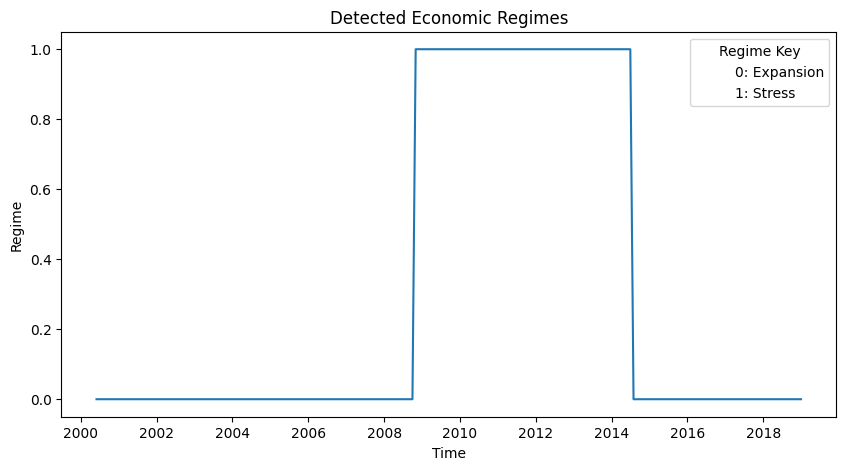

In [18]:
plt.figure(figsize=(10,5))
plt.plot(hmm_data.index, hmm_data['regime'])

# Add empty plots to create custom legend entries
plt.plot([], [], ' ', label="0: Expansion")
plt.plot([], [], ' ', label="1: Stress")

plt.title("Detected Economic Regimes")
plt.legend(title="Regime Key") # Added a title to clarify the legend
plt.xlabel("Time")
plt.ylabel("Regime")
#plt.savefig('regime_plot.png')
plt.show()


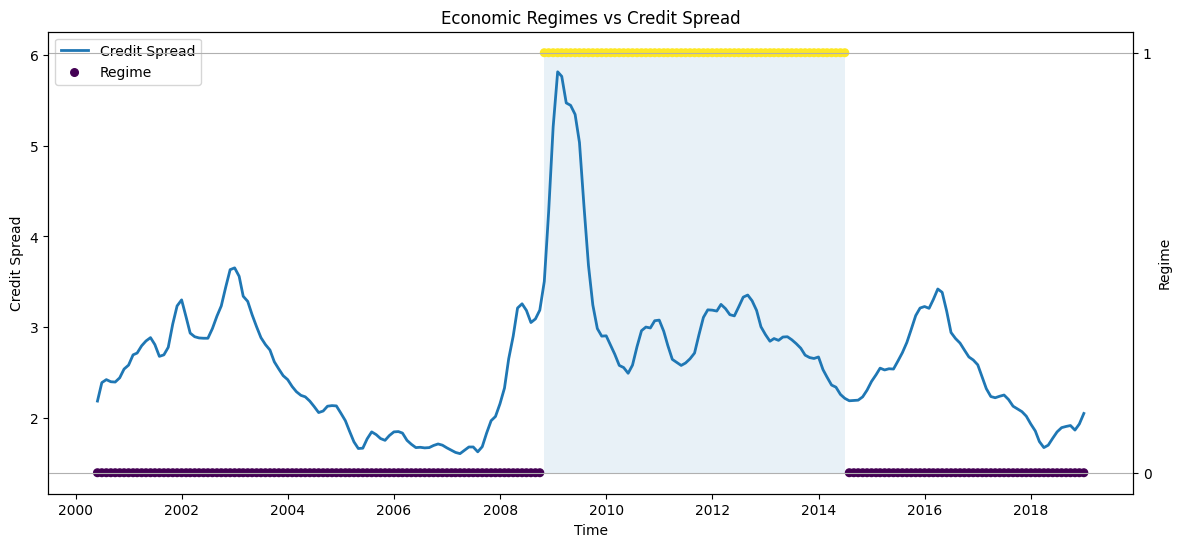

In [54]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 6))

# -----------------------------
# Plot Credit Spread
# -----------------------------
ax1.plot(
    hmm_data.index,
    hmm_data['credit_spread_lag1'],
    linewidth=2,
    label='Credit Spread'
)

ax1.set_xlabel('Time')
ax1.set_ylabel('Credit Spread')

# -----------------------------
# Secondary axis for Regimes
# -----------------------------
ax2 = ax1.twinx()

ax2.scatter(
    hmm_data.index,
    hmm_data['regime'],
    c=hmm_data['regime'],
    cmap='viridis',
    marker='o',
    s=30,
    label='Regime'
)

ax2.set_ylabel('Regime')
ax2.set_yticks([0, 1])

# -----------------------------
# Title
# -----------------------------
plt.title('Economic Regimes vs Credit Spread')

# -----------------------------
# Combine Legends
# -----------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left'
)

stress_periods = hmm_data['regime'] == 1

ax1.fill_between(
    hmm_data.index,
    ax1.get_ylim()[0],
    ax1.get_ylim()[1],
    where=stress_periods,
    alpha=0.1
)

plt.grid(True)

plt.show()

**4.2Regime Transition Matrix**

In [20]:
import pandas as pd

transition_matrix = pd.DataFrame(
    model.transmat_,
    columns=[f"to_{i}" for i in range(model.n_components)],
    index=[f"from_{i}" for i in range(model.n_components)]
)

print(transition_matrix)

            to_0      to_1
from_0  0.993489  0.006511
from_1  0.014534  0.985466


**4.3 Comparision of Default Rates by Regime**

In [21]:
default_rates_by_regime = merged.groupby('regime')['default'].mean().reset_index()
default_rates_by_regime['regime_label'] = default_rates_by_regime['regime'].map(label_map)
print("Default Rates by Economic Regime:")
display(default_rates_by_regime)

Default Rates by Economic Regime:


,regime,default,regime_label
0,0,0.110922,Expansion
1,1,0.160448,Stress


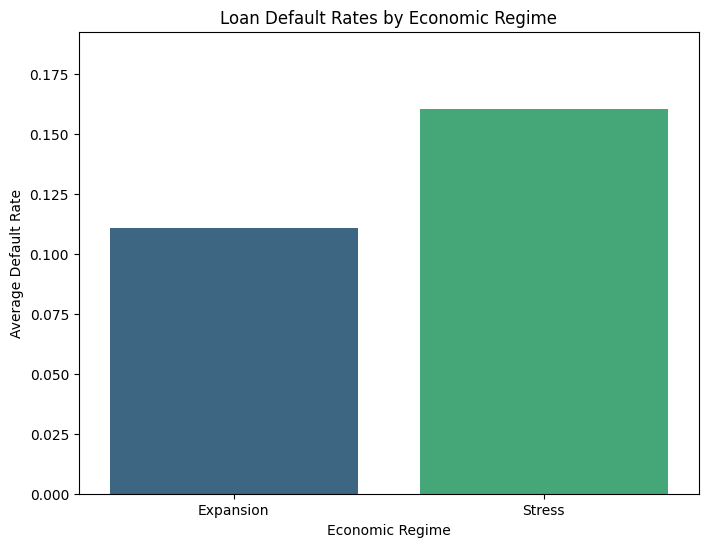

In [22]:
plt.figure(figsize=(8, 6))
sns.barplot(x='regime_label', y='default', data=default_rates_by_regime, hue='regime_label', palette='viridis', legend=False)
plt.title('Loan Default Rates by Economic Regime')
plt.xlabel('Economic Regime')
plt.ylabel('Average Default Rate')
plt.ylim(0, default_rates_by_regime['default'].max() * 1.2)
plt.show()

**5.0 Building the Pipeline for the Three Models (Borrower only, Borrower + Macroeconomic Features, Borrower + Macroeconomic + regime)**

**Model 1**: Borrower Only Features

$PD = Pr(default|X_{borrower features})$

In [24]:
borrower_features = [
    'loan_amnt',
    'term',
    'int_rate',
    'annual_inc',
    'dti',
    'fico_range_low',
    'installment',
    'revol_util'
]

**Model 2**: Borrower + Macroeconomic Features

$PD = Pr(default|X_{borrower features}, X_{macro features})$

In [26]:
macro_features = [
    'unemployment_lag1',
    'cpi_inflation_lag1',
    'ip_growth_lag1',
    'credit_spread_lag1',
    'yield_curve_lag1'
]

**Model 3**: Borrower + Macroeconomic + Regime Features

$PD = Pr(default|X_{borrower features}, X_{macro features}, R_t)$

where $R_t$ is regime at time $t$

In [27]:
regime_features = ['regime']

**5.1 Constructing Fearure Matrices**

In [28]:
X1 = merged[borrower_features]

X2 = merged[
    borrower_features + macro_features
]

X3 = merged[
    borrower_features + macro_features + regime_features
]

y = merged['default']

**5.2 Time-Based Train/Test Split**

In [29]:
merged = merged.sort_values('issue_month')

split_date = merged['issue_month'].quantile(0.8)

train_idx = merged['issue_month'] <= split_date
test_idx  = merged['issue_month'] > split_date

#Model Split
X1_train, X1_test = X1[train_idx], X1[test_idx]
X2_train, X2_test = X2[train_idx], X2[test_idx]
X3_train, X3_test = X3[train_idx], X3[test_idx]

y_train, y_test = y[train_idx], y[test_idx]

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6868\4206790703.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X1_train, X1_test = X1[train_idx], X1[test_idx]
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6868\4206790703.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X1_train, X1_test = X1[train_idx], X1[test_idx]
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6868\4206790703.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X2_train, X2_test = X2[train_idx], X2[test_idx]
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6868\4206790703.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X2_train, X2_test = X2[train_idx], X2[test_idx]
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6868\4206790703.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X3_train, X3_test = X3[train_idx], X3[test_idx]
C:\Users\ADMIN\AppData\Local\Temp\ipy

**5.3 One-hot Encoding for Categorical data**

In [31]:
X1_train = pd.get_dummies(X1_train, drop_first=True)
X1_test  = pd.get_dummies(X1_test, drop_first=True)

X2_train = pd.get_dummies(X2_train, drop_first=True)
X2_test  = pd.get_dummies(X2_test, drop_first=True)

X3_train = pd.get_dummies(X3_train, drop_first=True)
X3_test  = pd.get_dummies(X3_test, drop_first=True)

**5.4 Alignment of Columns**

In [32]:
#Column Alignment
X1_train, X1_test = X1_train.align(X1_test, join='left', axis=1, fill_value=0)

X2_train, X2_test = X2_train.align(X2_test, join='left', axis=1, fill_value=0)

X3_train, X3_test = X3_train.align(X3_test, join='left', axis=1, fill_value=0)

# Class Imbalance Handling
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print(scale_pos_weight)

5.9829244618693265


**5.5 Define XGBoost Model Training Function**

In [33]:
from xgboost import XGBClassifier

def train_xgb(X_train, y_train):

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )

    model.fit(X_train, y_train)

    return model

**5.6 Train the Three Models**

In [34]:
model1 = train_xgb(X1_train, y_train)

model2 = train_xgb(X2_train, y_train)

model3 = train_xgb(X3_train, y_train)

**6.0 Evaluation of the Three Models**

In [35]:
#Model Evaluation Helper Function
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score
)

def evaluate_model(model, X_test, y_test):

    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob > 0.5).astype(int)

    roc_auc = roc_auc_score(y_test, y_prob)

    pr_auc = average_precision_score(y_test, y_prob)

    accuracy = accuracy_score(y_test, y_pred)

    return {
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc,
        'Accuracy': accuracy
    }

#Evaluation of the Models
results1 = evaluate_model(model1, X1_test, y_test)

results2 = evaluate_model(model2, X2_test, y_test)

results3 = evaluate_model(model3, X3_test, y_test)

print("Model 1:", results1)
print("Model 2:", results2)
print("Model 3:", results3)

Model 1: {'ROC_AUC': np.float64(0.6830615124575465), 'PR_AUC': np.float64(0.026775830238079047), 'Accuracy': 0.6321310152082957}
Model 2: {'ROC_AUC': np.float64(0.7045307245324146), 'PR_AUC': np.float64(0.03822115185008962), 'Accuracy': 0.9682575812685235}
Model 3: {'ROC_AUC': np.float64(0.7145909572788003), 'PR_AUC': np.float64(0.04213789966520837), 'Accuracy': 0.973039946122131}


**6.1 Visualization of Model Performance**

In [44]:
model_performance = {
    'Model 1': {
        'y_test': y_test,
        'y_pred_proba': model1.predict_proba(X1_test)[:, 1]
    },

    'Model 2': {
        'y_test': y_test,
        'y_pred_proba': model2.predict_proba(X2_test)[:, 1]
    },

    'Model 3': {
        'y_test': y_test,
        'y_pred_proba': model3.predict_proba(X3_test)[:, 1]
    }
}

**6.11 Precision-Recall Curve**


Plotting Precision-Recall Curves:


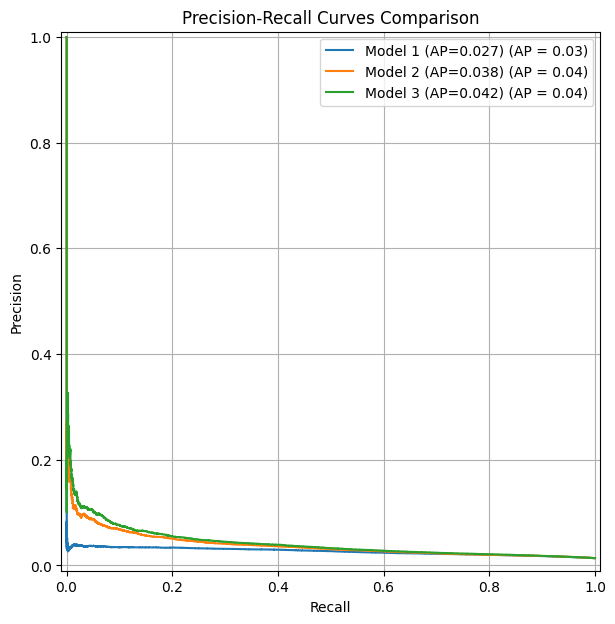

In [47]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

print('\nPlotting Precision-Recall Curves:')

plt.figure(figsize=(10, 7))
ax = plt.gca()

for model_name, results in model_performance.items():

    # Compute PR-AUC
    pr_auc = average_precision_score(
        results['y_test'],
        results['y_pred_proba']
    )

    # Plot curve
    PrecisionRecallDisplay.from_predictions(
        results['y_test'],
        results['y_pred_proba'],
        name=f"{model_name} (AP={pr_auc:.3f})",
        ax=ax
    )

plt.title('Precision-Recall Curves Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.grid(True)

plt.legend(loc='upper right')

plt.show()

**6.12 Receiver Operating Characteristic (ROC) Curve**


Plotting ROC Curves:


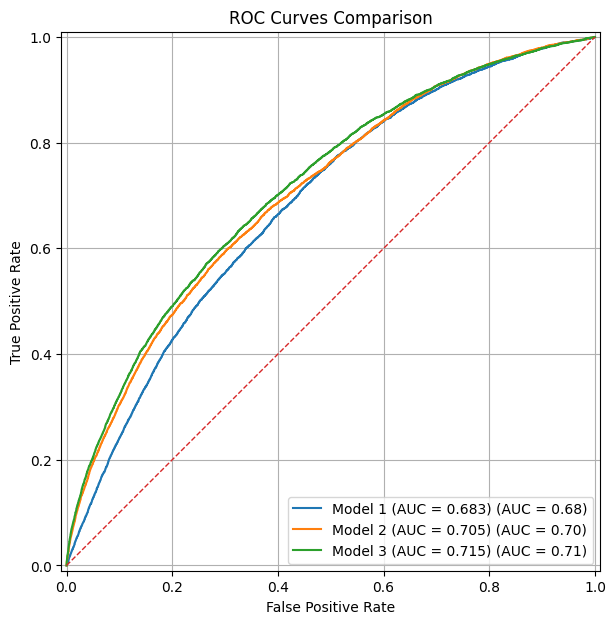

In [48]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

print('\nPlotting ROC Curves:')

plt.figure(figsize=(10, 7))
ax = plt.gca()

for model_name, results in model_performance.items():

    # Compute ROC-AUC
    roc_auc = roc_auc_score(
        results['y_test'],
        results['y_pred_proba']
    )

    # Plot ROC Curve
    RocCurveDisplay.from_predictions(
        results['y_test'],
        results['y_pred_proba'],
        name=f"{model_name} (AUC = {roc_auc:.3f})",
        ax=ax
    )

# Plot random classifier benchmark
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.grid(True)

plt.legend(loc='lower right')

plt.show()

**6.2 Brier Scores for each Model**

In [49]:
from sklearn.metrics import brier_score_loss

for model_name, results in model_performance.items():

    brier = brier_score_loss(
        results['y_test'],
        results['y_pred_proba']
    )

    print(f"{model_name} Brier Score: {brier:.5f}")

Model 1 Brier Score: 0.21789
Model 2 Brier Score: 0.06319
Model 3 Brier Score: 0.05747


**6.3 Calibration Curve**


Plotting Calibration Curves:


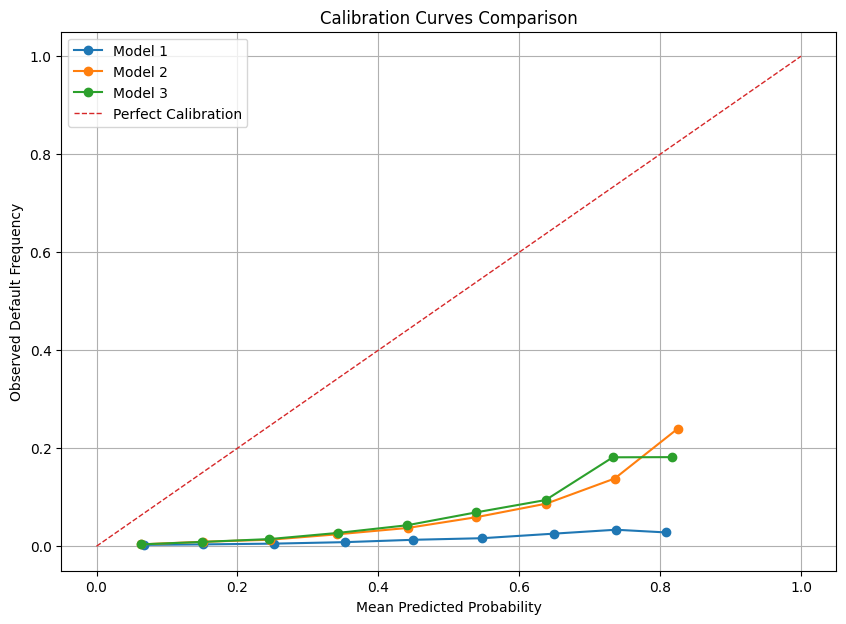

In [50]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

print('\nPlotting Calibration Curves:')

plt.figure(figsize=(10, 7))

for model_name, results in model_performance.items():

    # Compute calibration curve
    prob_true, prob_pred = calibration_curve(
        results['y_test'],
        results['y_pred_proba'],
        n_bins=10,
        strategy='uniform'
    )

    # Plot calibration curve
    plt.plot(
        prob_pred,
        prob_true,
        marker='o',
        label=model_name
    )

# Perfect calibration reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    label='Perfect Calibration'
)

plt.title('Calibration Curves Comparison')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Default Frequency')

plt.grid(True)

plt.legend(loc='upper left')

plt.show()

**7.0 Stress Testing the Models**